#Isoform Specificity (Tau)

In [ ]:
print("Hello World")

In [1]:
import logging
logging.getLogger("fontTools").setLevel(logging.WARNING)

import os
_r = os.path.abspath(".")
while _r != os.path.dirname(_r) and not os.path.exists(os.path.join(_r, ".notebooks_root")):
    _r = os.path.dirname(_r)
os.chdir(_r if os.path.exists(os.path.join(_r, ".notebooks_root")) else "/oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks")  # cd to notebooks/ root (marked .notebooks_root); relocation-proof

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import issparse
import warnings, os, sys, gc
warnings.filterwarnings('ignore')
gc.enable()

sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

BASEDIR = "./../pacbio"
H5AD_DIR = f"{BASEDIR}/h5ads"

# reload figure_paths: a live kernel caches FIG_MAP
import importlib
import figure_paths
importlib.reload(figure_paths)
from figure_paths import figpath  # routes figures/ -> figures/figureN/ via FIG_MAP


In [2]:
# preferred plot formatting
import matplotlib
import matplotlib.legend as _mlegend
from matplotlib import pyplot as plt

matplotlib.rcParams['pdf.fonttype'] = 42      # editable text in PDF/PS (not outlines)
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial'] + matplotlib.rcParams['font.sans-serif']
# Mathtext (anything in $...$) otherwise falls back to DejaVu Sans, so Greek letters,
# superscripts and subscripts render in a different family from the surrounding Arial.
# "custom" + the four Arial families keeps the whole figure in one typeface.
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Arial'
matplotlib.rcParams['mathtext.it'] = 'Arial:italic'
matplotlib.rcParams['mathtext.bf'] = 'Arial:bold'

# tunable spacing (points) — override per-plot as needed
TICK_LEN = 2.0          # tick-mark length
TICK_LABEL_PAD = 1.5    # gap between ticks and tick labels
AXIS_LABEL_PAD = 1.5    # gap between axis and its axis label
PANEL_TITLE_PAD = 3.0   # gap between subplot titles and their axes (pass explicitly)
plt.rcParams.update({
    "font.size": 6,
    "axes.titlesize": 6,
    "axes.labelsize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "legend.title_fontsize": 6,
    "legend.labelspacing": 0.1,
    "legend.borderpad": 0.3,
    "legend.handletextpad": 0.2,
    "figure.titlesize": 6,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "figure.titleweight": "bold",
    "xtick.major.size": TICK_LEN,
    "ytick.major.size": TICK_LEN,
    "xtick.major.pad": TICK_LABEL_PAD,
    "ytick.major.pad": TICK_LABEL_PAD,
    "axes.labelpad": AXIS_LABEL_PAD,
    "axes.titlepad": PANEL_TITLE_PAD,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

# Legend-title weight has no rcParam -> make every legend title bold by default.
if not getattr(_mlegend.Legend, "_bold_title_patched", False):
    _orig_set_title = _mlegend.Legend.set_title
    def _bold_set_title(self, title, prop=None):
        res = _orig_set_title(self, title, prop=prop)
        self.get_title().set_fontweight("bold")
        return res
    _mlegend.Legend.set_title = _bold_set_title
    _mlegend.Legend._bold_title_patched = True

#1. Load data, merge cell types

In [3]:
adata = sc.read_h5ad(f"{H5AD_DIR}/all_samples_pacbio_recollapsed_raw_counts_ensemblids_bc_anndata_preprocessed_with_isofrac.h5ad")
print(f"Loaded: {adata.shape[0]} cells x {adata.shape[1]} isoforms")

# Determine gene column
gene_col = "associated_gene" if "associated_gene" in adata.var.columns else "gene_name"
print(f"Using gene column: {gene_col}")

# Extract tissue
if "tissue" not in adata.obs.columns:
    parts = adata.obs.index.str.split("_")
    adata.obs["tissue"] = ["_".join(p[1:]) if len(p) > 1 else "unknown" for p in parts]

# Filter to genes with >= 2 isoforms (already filtered to >=10 cells in saved h5ad)
gene_counts = adata.var[gene_col].value_counts()
multi_iso_genes = gene_counts[gene_counts >= 2].index
multi_mask = adata.var[gene_col].isin(multi_iso_genes)
adata = adata[:, multi_mask].copy()
print(f"After multi-isoform filter: {adata.shape} ({len(multi_iso_genes)} genes with >=2 isoforms)")
gc.collect()

Loaded: 203311 cells x 478192 isoforms
Using gene column: gene_name
After multi-isoform filter: (203311, 478192) (26940 genes with >=2 isoforms)


723

#2. Per-gene Tau of isoform usage per cell type

For each gene in each cell type, compute the mean isoform fraction across cells, then compute the Tau specificity index:

$$\tau = \frac{\sum_{i=1}^{n}\left(1 - \frac{f_i}{\max(f)}\right)}{n - 1}$$

where $f_i$ is the mean fraction of isoform $i$ and $n$ is the number of expressed isoforms ($f_i > 0$).

Tau ranges from 0 (all isoforms equally used) to 1 (one dominant isoform). Genes with only 1 expressed isoform are skipped (tau undefined).

In [4]:
from scipy.sparse import csc_matrix as _csc_matrix

frac_mat = adata.layers["isoform_fraction"]
genes = adata.var[gene_col].values

# Build isoform-to-gene mapping matrix for vectorized n_expr computation
unique_genes, gene_indices = np.unique(genes, return_inverse=True)
n_genes_unique = len(unique_genes)
n_isoforms = len(genes)

iso_to_gene = _csc_matrix(
    (np.ones(n_isoforms, dtype=np.float32), (np.arange(n_isoforms), gene_indices)),
    shape=(n_isoforms, n_genes_unique)
)

# Precompute column indices per gene
gene_col_indices = [np.where(gene_indices == g)[0] for g in range(n_genes_unique)]

# Convert to CSC for efficient column-sum operations
if issparse(frac_mat):
    frac_csc = frac_mat.tocsc()
else:
    frac_csc = frac_mat

cell_types = sorted([ct for ct in adata.obs["cell_ontology_class"].unique() if ct != "unknown"])
print(f"Computing Tau specificity index for {n_genes_unique} genes x {len(cell_types)} cell types")

tau_records = []
for ct_i, ct in enumerate(cell_types):
    ct_mask = (adata.obs["cell_ontology_class"] == ct).values
    n_cells_ct = ct_mask.sum()
    if n_cells_ct < 10:
        continue

    frac_ct = frac_csc[ct_mask, :]

    # Column sums: total isoform fraction per isoform across all cells of this type
    col_sums = np.asarray(frac_ct.sum(axis=0)).ravel()

    # Number of expressing cells per gene via sparse matmul
    gene_expr_per_cell = (frac_ct > 0).astype(np.float32) @ iso_to_gene
    n_expr_per_gene = np.asarray((gene_expr_per_cell > 0).sum(axis=0)).ravel()

    # Compute Tau per gene
    for g_idx in range(n_genes_unique):
        n_expr = int(n_expr_per_gene[g_idx])
        if n_expr < 5:
            continue
        col_idx = gene_col_indices[g_idx]
        n_iso = len(col_idx)
        if n_iso < 2:
            continue
        mean_fracs = col_sums[col_idx] / n_expr
        mean_fracs = mean_fracs[mean_fracs > 0]
        if len(mean_fracs) <= 1:
            continue
        x_max = mean_fracs.max()
        tau = float(np.sum(1 - mean_fracs / x_max) / (len(mean_fracs) - 1))
        tau_records.append({"gene": unique_genes[g_idx], "cell_ontology_class": ct, "tau": tau,
                             "n_isoforms": n_iso, "n_cells_expr": n_expr})

    if (ct_i + 1) % 20 == 0:
        print(f"  Processed {ct_i + 1} / {len(cell_types)} cell types")

print(f"  Processed {ct_i + 1} / {len(cell_types)} cell types")
tau_df = pd.DataFrame(tau_records)
print(f"Tau table: {tau_df.shape[0]} gene-celltype pairs")
print(f"Tau range: [{tau_df['tau'].min():.4f}, {tau_df['tau'].max():.4f}]")
tau_df.head(10)

Computing Tau specificity index for 26940 genes x 144 cell types
  Processed 20 / 144 cell types
  Processed 40 / 144 cell types
  Processed 60 / 144 cell types
  Processed 80 / 144 cell types
  Processed 100 / 144 cell types
  Processed 120 / 144 cell types
  Processed 144 / 144 cell types
Tau table: 1013649 gene-celltype pairs
Tau range: [0.0000, 1.0000]


,gene,cell_ontology_class,tau,n_isoforms,n_cells_expr
0,A1BG,acinar cell of salivary gland,0.976923,9,133
1,A1BG-AS1,acinar cell of salivary gland,0.760000,20,11
2,A2M,acinar cell of salivary gland,0.976081,43,357
3,A4GALT,acinar cell of salivary gland,0.938270,22,162
4,AAAS,acinar cell of salivary gland,0.886555,24,127
5,AACS,acinar cell of salivary gland,0.910547,14,183
6,AAGAB,acinar cell of salivary gland,0.592000,18,76
7,AAK1,acinar cell of salivary gland,0.992486,32,396
8,AAMDC,acinar cell of salivary gland,0.931494,83,191
9,AAMP,acinar cell of salivary gland,0.876667,52,546


In [5]:
# Save per gene-cell type tau measure
outdir = "./../csvs"
tau_df.to_csv(f"{outdir}/all_samples_recollapsed_tau_per_gene_celltype.csv", index=False)
print(f"Saved: {outdir}/all_samples_recollapsed_tau_per_gene_celltype.csv ({tau_df.shape[0]} rows)")

Saved: ./../csvs/all_samples_recollapsed_tau_per_gene_celltype.csv (1013649 rows)


#3. Rank genes by isoform specificity

In [6]:
# Mean Tau across cell types per gene
gene_tau = tau_df.groupby("gene")["tau"].agg(["mean", "std", "count"]).reset_index()
gene_tau.columns = ["gene", "mean_tau", "std_tau", "n_celltypes"]
gene_tau = gene_tau.sort_values("mean_tau", ascending=False)

print("Top 20 highest isoform specificity genes (by Tau):")
print(gene_tau.head(20).to_string(index=False))

print("\nTop 20 lowest isoform specificity genes (>= 5 cell types):")
low_spec = gene_tau[gene_tau["n_celltypes"] >= 5].sort_values("mean_tau")
print(low_spec.head(20).to_string(index=False))

# Distribution of number of isoforms per gene
isoforms_per_gene = adata.var[gene_col].value_counts()
median_iso = isoforms_per_gene.median()
mean_iso = isoforms_per_gene.mean()
print(f"\nIsoforms per gene: median={median_iso:.0f}, mean={mean_iso:.1f}")

Top 20 highest isoform specificity genes (by Tau):
           gene  mean_tau  std_tau  n_celltypes
        IGHV6-1  0.999805      NaN            1
 IGLC2+IGLV5-45  0.999780      NaN            1
         BOD1L2  0.999749 0.000050            2
ENSG00000267857  0.999714      NaN            1
ENSG00000196656  0.999623 0.000765           33
         MALAT1  0.999518 0.002629          127
       CXorf51B  0.999359 0.000157            2
         ACTL7A  0.999328 0.000132            2
          FOXQ1  0.999319 0.000519            2
          MYH16  0.999307      NaN            1
       CXorf51A  0.999217 0.000366            2
        SPANXB1  0.999201 0.000038            2
        SCGB1A1  0.999131 0.000988           16
           H4C3  0.999092 0.000896            9
           H1-7  0.999079 0.000401            2
           CST3  0.998920 0.001789           85
          COX8A  0.998919 0.003938           34
         SPANXD  0.998893 0.000048            2
          GNG11  0.998882 0.001655   

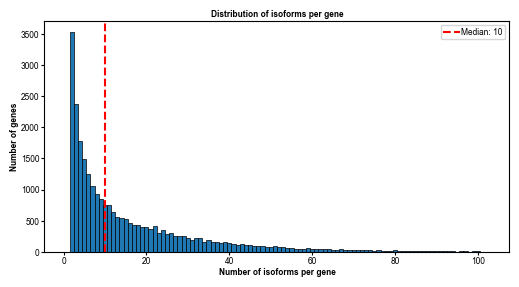

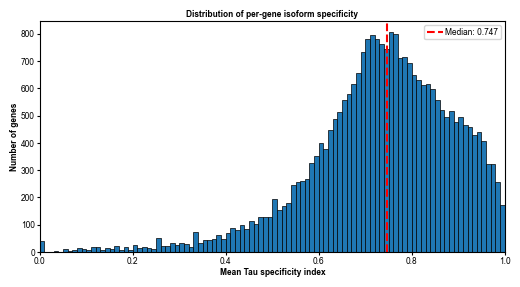

In [7]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(isoforms_per_gene.values, bins=np.arange(0.5, isoforms_per_gene.quantile(0.99) + 1.5, 1),
        edgecolor="black", linewidth=0.5)
ax.set_xlabel("Number of isoforms per gene")
ax.set_ylabel("Number of genes")
ax.set_title("Distribution of isoforms per gene")
ax.axvline(median_iso, color="red", linestyle="--",
           label=f"Median: {median_iso:.0f}")
ax.legend()
plt.savefig(figpath("04_04_isoforms_per_gene_distribution.pdf"))
plt.show()

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(gene_tau["mean_tau"], bins=100, edgecolor="black", linewidth=0.5)
ax.set_xlabel("Mean Tau specificity index")
ax.set_ylabel("Number of genes")
ax.set_title("Distribution of per-gene isoform specificity")
ax.set_xlim(0, 1)
ax.axvline(gene_tau["mean_tau"].median(), color="red", linestyle="--",
           label=f"Median: {gene_tau['mean_tau'].median():.3f}")
ax.legend()
plt.savefig(figpath("04_04_per_gene_tau_distribution.pdf"))
plt.show()

#4. Compare Tau across cell types

In [8]:
# Mean number of isoforms per gene, by cell type
ct_mean_n_isoforms = tau_df.groupby("cell_ontology_class")["n_isoforms"].mean().sort_values(ascending=False)
median_ct_iso = ct_mean_n_isoforms.median()

# Mean Tau by cell type
ct_mean_tau = tau_df.groupby("cell_ontology_class")["tau"].mean().sort_values(ascending=False)

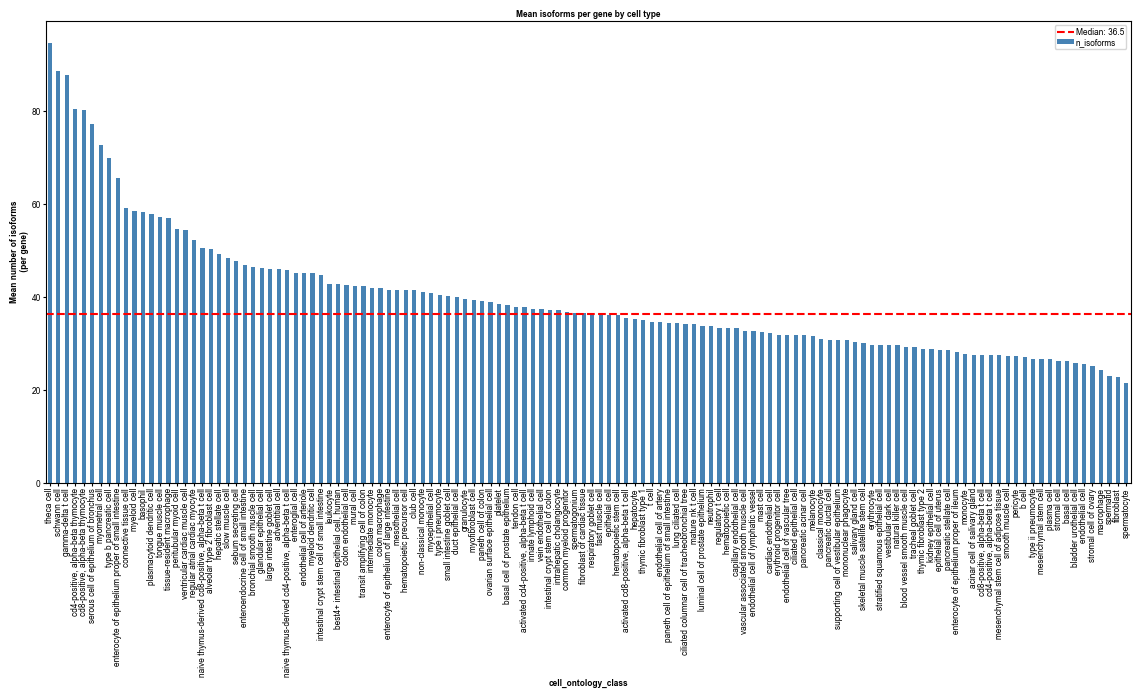

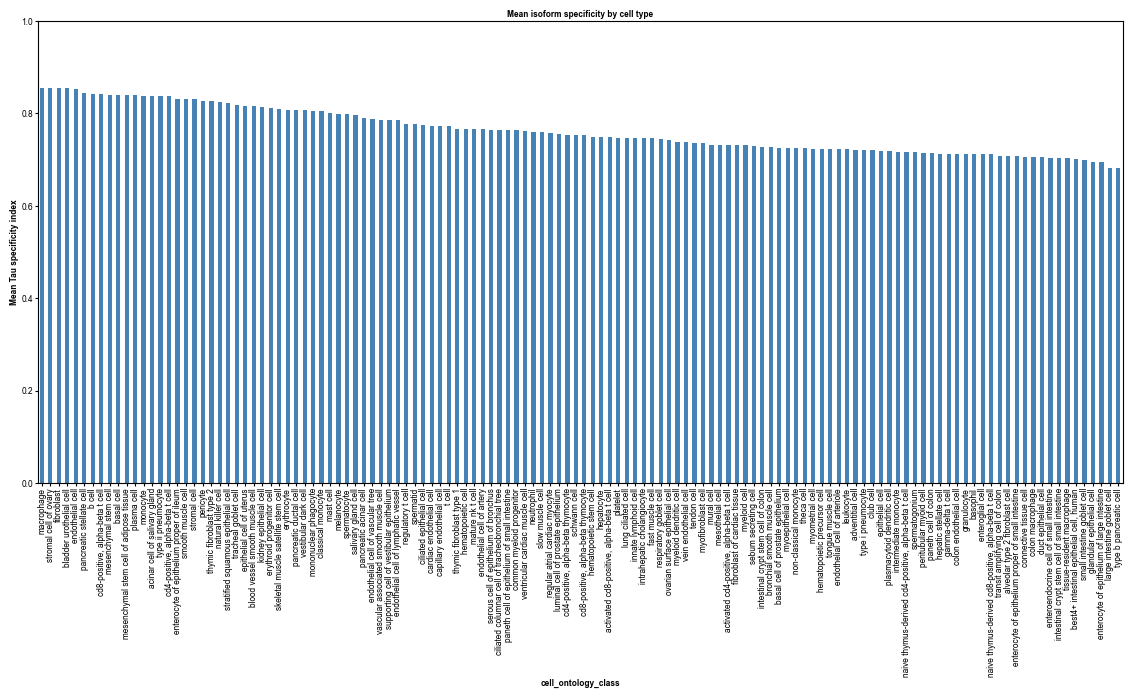

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))
ct_mean_n_isoforms.plot(kind="bar", ax=ax, color="steelblue")
ax.axhline(median_ct_iso, color="red", linestyle="--", label=f"Median: {median_ct_iso:.1f}")
ax.set_ylabel("Mean number of isoforms\n (per gene)")
ax.set_title("Mean isoforms per gene by cell type")
ax.legend()
plt.xticks(rotation=90)
plt.savefig(figpath("04_04_mean_isoforms_per_gene_by_celltype.pdf"))
plt.show()

fig, ax = plt.subplots(figsize=(14, 6))
ct_mean_tau.plot(kind="bar", ax=ax, color="steelblue")
ax.set_ylabel("Mean Tau specificity index")
ax.set_ylim(0, 1)
ax.set_title("Mean isoform specificity by cell type")
plt.xticks(rotation=90)
plt.savefig(figpath("04_04_mean_tau_by_celltype.pdf"))
plt.show()

#5. Compare Tau across tissues

In [10]:
# Compute Tau per gene per tissue (reuses frac_csc, iso_to_gene, gene_col_indices from above)
tissues = sorted(adata.obs["tissue"].unique())
tissue_tau_records = []
for t_i, tissue in enumerate(tissues):
    t_mask = (adata.obs["tissue"] == tissue).values
    if t_mask.sum() < 10:
        continue

    frac_t = frac_csc[t_mask, :]
    col_sums = np.asarray(frac_t.sum(axis=0)).ravel()
    gene_expr_per_cell = (frac_t > 0).astype(np.float32) @ iso_to_gene
    n_expr_per_gene = np.asarray((gene_expr_per_cell > 0).sum(axis=0)).ravel()

    for g_idx in range(n_genes_unique):
        n_expr = int(n_expr_per_gene[g_idx])
        if n_expr < 5:
            continue
        col_idx = gene_col_indices[g_idx]
        n_iso = len(col_idx)
        if n_iso < 2:
            continue
        mean_fracs = col_sums[col_idx] / n_expr
        mean_fracs = mean_fracs[mean_fracs > 0]
        if len(mean_fracs) <= 1:
            continue
        x_max = mean_fracs.max()
        tau = float(np.sum(1 - mean_fracs / x_max) / (len(mean_fracs) - 1))
        tissue_tau_records.append({"gene": unique_genes[g_idx], "tissue": tissue,
                                    "tau": tau, "n_isoforms": n_iso})

    print(f"  Tissue {t_i + 1}/{len(tissues)}: {tissue}")

tissue_tau_df = pd.DataFrame(tissue_tau_records)

# Mean number of isoforms per gene, by tissue
tissue_mean_n_iso = tissue_tau_df.groupby("tissue")["n_isoforms"].mean().sort_values(ascending=False)
median_tissue_iso = tissue_mean_n_iso.median()

# Mean Tau by tissue
tissue_mean = tissue_tau_df.groupby("tissue")["tau"].mean().sort_values(ascending=False)

  Tissue 1/26: Bladder
  Tissue 2/26: Blood
  Tissue 3/26: Bone_Marrow
  Tissue 4/26: Ear
  Tissue 5/26: Fat
  Tissue 6/26: Heart
  Tissue 7/26: Kidney
  Tissue 8/26: Large_Intestine
  Tissue 9/26: Liver
  Tissue 10/26: Lung
  Tissue 11/26: Lymph_Node
  Tissue 12/26: Muscle
  Tissue 13/26: Ovary
  Tissue 14/26: Pancreas
  Tissue 15/26: Prostate
  Tissue 16/26: Salivary_Gland
  Tissue 17/26: Skin
  Tissue 18/26: Small_Intestine
  Tissue 19/26: Spleen
  Tissue 20/26: Stomach
  Tissue 21/26: Testis
  Tissue 22/26: Thymus
  Tissue 23/26: Tongue
  Tissue 24/26: Trachea
  Tissue 25/26: Uterus
  Tissue 26/26: Vasculature


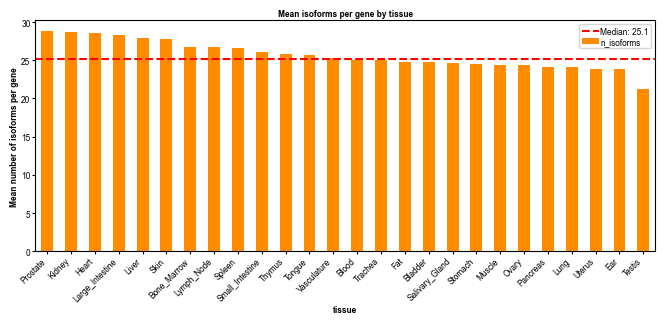

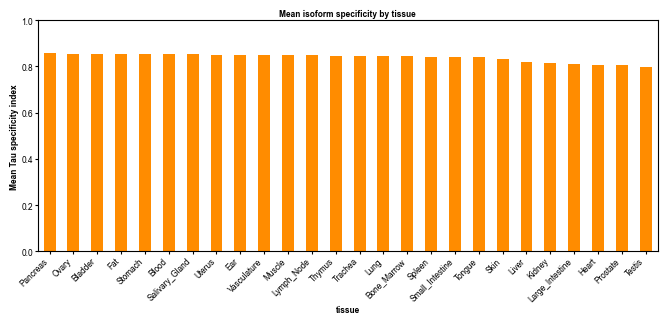

In [11]:
fig, ax = plt.subplots(figsize=(8, 3))
tissue_mean_n_iso.plot(kind="bar", ax=ax, color="darkorange")
ax.axhline(median_tissue_iso, color="red", linestyle="--", label=f"Median: {median_tissue_iso:.1f}")
ax.set_ylabel("Mean number of isoforms per gene")
ax.set_title("Mean isoforms per gene by tissue")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.savefig(figpath("04_04_mean_isoforms_per_gene_by_tissue.pdf"))
plt.show()

fig, ax = plt.subplots(figsize=(8, 3))
tissue_mean.plot(kind="bar", ax=ax, color="darkorange")
ax.set_ylabel("Mean Tau specificity index")
ax.set_ylim(0, 1)
ax.set_title("Mean isoform specificity by tissue")
plt.xticks(rotation=45, ha="right")
plt.savefig(figpath("04_04_mean_tau_by_tissue.pdf"))
plt.show()

#6. Scatter: Tau in cell type A vs cell type B

In [12]:
# Mean Tau per cell type (computed in section 4)
ct_mean_tau = tau_df.groupby("cell_ontology_class")["tau"].mean().sort_values(ascending=False)

# Map popv_prediction -> broad_cell_class (via popv_to_ts_map then ts_broad_map)
popv_to_ts = pd.read_csv("./../csvs/popv_to_ts_celltype_mapping.csv")
ts_celltypes = pd.read_csv("./../csvs/ts_celltypes.csv")
popv_to_ts_map = dict(zip(popv_to_ts["popv_prediction"], popv_to_ts["ts_cell_ontology_class"]))
ts_broad_map = dict(zip(ts_celltypes["cell_ontology_class"], ts_celltypes["broad_cell_class"]))

ct_to_broad = {ct: ts_broad_map.get(ct, "unknown")
               for ct in ct_mean_tau.index}

# --- Left plot: top two highest mean tau from the SAME broad_cell_class ---
same_pair = None
for i, ct_a in enumerate(ct_mean_tau.index):
    for ct_b in ct_mean_tau.index[i + 1:]:
        if ct_to_broad[ct_a] == ct_to_broad[ct_b] and ct_to_broad[ct_a] != "unknown":
            same_pair = [ct_a, ct_b]
            break
    if same_pair is not None:
        break

# --- Right plot: top two highest mean tau from DIFFERENT broad_cell_classes ---
diff_pair = None
for i, ct_a in enumerate(ct_mean_tau.index):
    for ct_b in ct_mean_tau.index[i + 9:]:
        if ct_to_broad[ct_a] != ct_to_broad[ct_b]:
            diff_pair = [ct_a, ct_b]
            break
    if diff_pair is not None:
        break

# Pivot tables + correlations for the two panels
tau_pivot1 = tau_df[tau_df["cell_ontology_class"].isin(same_pair)].pivot_table(
    index="gene", columns="cell_ontology_class", values="tau"
).dropna()
r1 = tau_pivot1.corr().iloc[0, 1]

tau_pivot2 = tau_df[tau_df["cell_ontology_class"].isin(diff_pair)].pivot_table(
    index="gene", columns="cell_ontology_class", values="tau"
).dropna()
r2 = tau_pivot2.corr().iloc[0, 1]

print(f"Same broad class ({ct_to_broad[same_pair[0]]}):\n"
      f"  {same_pair[0]} (mean Tau = {ct_mean_tau[same_pair[0]]:.3f})\n"
      f"  {same_pair[1]} (mean Tau = {ct_mean_tau[same_pair[1]]:.3f})")
print(f"\nDifferent broad classes:\n"
      f"  {diff_pair[0]} [{ct_to_broad[diff_pair[0]]}] (mean Tau = {ct_mean_tau[diff_pair[0]]:.3f})\n"
      f"  {diff_pair[1]} [{ct_to_broad[diff_pair[1]]}] (mean Tau = {ct_mean_tau[diff_pair[1]]:.3f})")

Same broad class (myeloid leukocyte):
  macrophage (mean Tau = 0.855)
  monocyte (mean Tau = 0.839)

Different broad classes:
  macrophage [myeloid leukocyte] (mean Tau = 0.855)
  basal cell [epithelial cell] (mean Tau = 0.840)


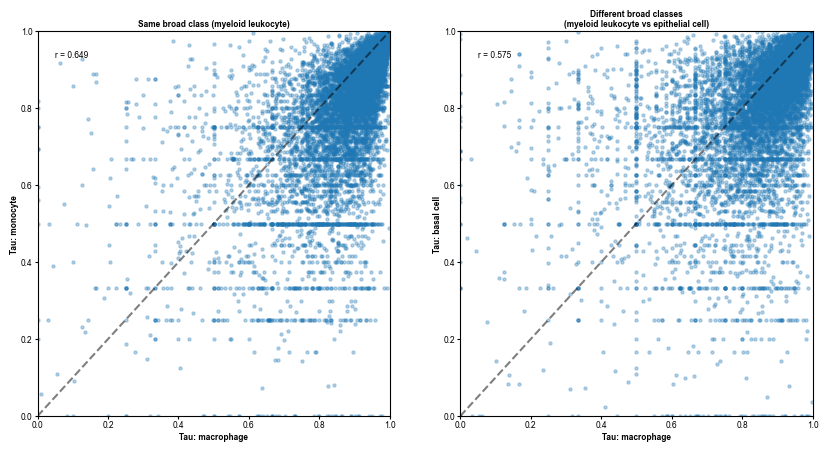

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# --- Plot 1: Same broad class ---
ax = axes[0]
ax.scatter(tau_pivot1[same_pair[0]], tau_pivot1[same_pair[1]], alpha=0.3, s=5)
ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax.set_xlabel(f"Tau: {same_pair[0]}")
ax.set_ylabel(f"Tau: {same_pair[1]}")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title(f"Same broad class ({ct_to_broad[same_pair[0]]})")
ax.text(0.05, 0.95, f"r = {r1:.3f}", transform=ax.transAxes, va="top")

# --- Plot 2: Different broad classes ---
ax = axes[1]
ax.scatter(tau_pivot2[diff_pair[0]], tau_pivot2[diff_pair[1]], alpha=0.3, s=5)
ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax.set_xlabel(f"Tau: {diff_pair[0]}")
ax.set_ylabel(f"Tau: {diff_pair[1]}")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title(f"Different broad classes\n({ct_to_broad[diff_pair[0]]} vs {ct_to_broad[diff_pair[1]]})")
ax.text(0.05, 0.95, f"r = {r2:.3f}", transform=ax.transAxes, va="top")

plt.savefig(figpath("04_04_tau_scatter_same_vs_diff_broadclass.pdf"))
plt.show()

#7. Genes with high between-cell-type Tau variance

In [14]:
# Per-gene Tau variance across cell types
gene_var = tau_df.groupby("gene").agg(
    mean_tau=("tau", "mean"),
    var_tau=("tau", "var"),
    n_isoforms=("n_isoforms", "first"),  # constant per gene
).reset_index()
gene_var = gene_var.sort_values("var_tau", ascending=False)

# Helper: select genes to label -- top by var_tau from each quartile of x
def select_label_genes(df, x_col, n_per_quartile=2):
    """Pick top var_tau genes from each quartile of x_col."""
    quartile_labels = pd.qcut(df[x_col], q=4, labels=False, duplicates="drop")
    parts = []
    for q in sorted(quartile_labels.unique()):
        q_df = df[quartile_labels == q]
        parts.append(q_df.nlargest(n_per_quartile, "var_tau"))
    return pd.concat(parts).drop_duplicates(subset="gene"), quartile_labels

# Select genes for labeling on scatter; also keep quartile labels for stacked bar selection
scatter_label_genes, _quartile_labels = select_label_genes(gene_var, "mean_tau")

# Top 1 per quartile for stacked bars
stacked_bar_genes = []
for q in sorted(_quartile_labels.unique()):
    q_df = gene_var[_quartile_labels == q]
    stacked_bar_genes.append(q_df.nlargest(1, "var_tau"))
stacked_bar_genes = pd.concat(stacked_bar_genes)

# Distribution of n_isoforms among top-variance genes
print("\nn_isoforms distribution among top 100 high-variance genes:")
print(gene_var.head(100)["n_isoforms"].describe().to_string())
print(f"\nn_isoforms=2 genes: {(gene_var['n_isoforms'] == 2).sum()} / {len(gene_var)} "
      f"({(gene_var['n_isoforms'] == 2).mean():.1%})")


n_isoforms distribution among top 100 high-variance genes:
count    100.000000
mean       3.170000
std        3.452579
min        2.000000
25%        2.000000
50%        2.000000
75%        3.000000
max       32.000000

n_isoforms=2 genes: 3309 / 26708 (12.4%)


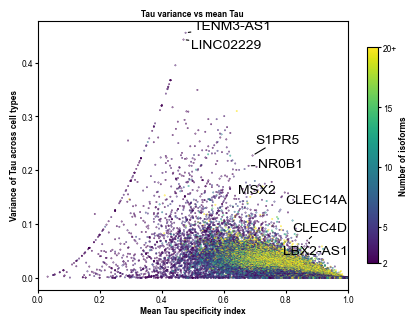

In [15]:
from adjustText import adjust_text

# --- Scatter: mean_tau vs var_tau, colored by n_isoforms ---
fig, ax = plt.subplots(figsize=(5, 3.5))

n_iso_capped = gene_var["n_isoforms"].clip(upper=20)
sc_plot = ax.scatter(gene_var["mean_tau"], gene_var["var_tau"],
                     c=n_iso_capped, cmap="viridis", alpha=1.0, s=0.1)
ax.set_xlabel("Mean Tau specificity index")
ax.set_ylabel("Variance of Tau across cell types")
ax.set_xlim(0, 1)
ax.set_title("Tau variance vs mean Tau")
cbar = plt.colorbar(sc_plot, ax=ax, label="Number of isoforms", shrink=0.8)
cbar.set_ticks([2, 5, 10, 15, 20])
cbar.set_ticklabels(["2", "5", "10", "15", "20+"])

# Label selected genes
texts = []
for _, row in scatter_label_genes.iterrows():
    texts.append(ax.text(row["mean_tau"], row["var_tau"], row["gene"],
                         fontsize=10, color="black", alpha=1.0))
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="black", lw=0.8),
    expand=(1.2, 1.5), force_text=(0.8, 1.0))

plt.savefig(figpath("04_04_tau_variance_vs_mean.pdf"))
plt.show()

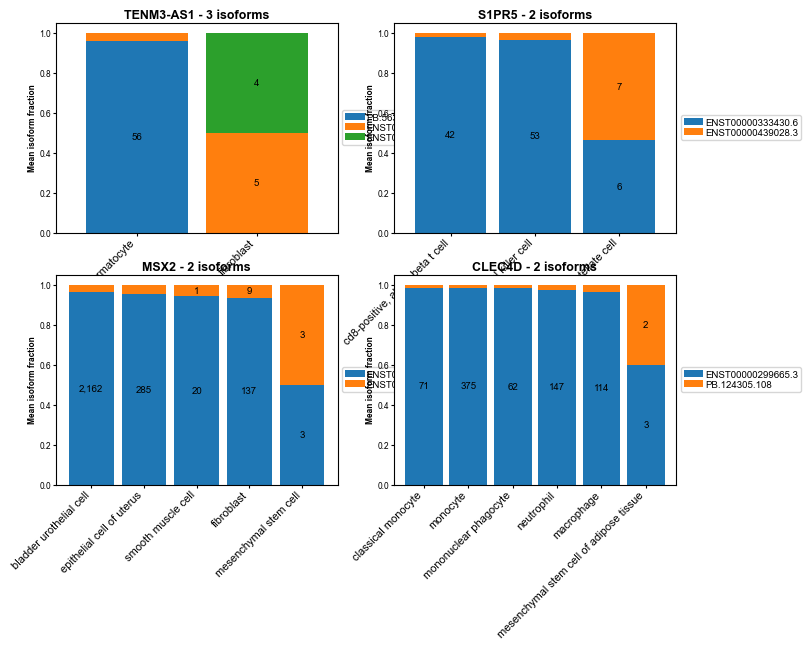

In [16]:
# Stacked bar: isoform proportions for top gene from each quartile of mean Tau
max_isoforms = 8
quartile_names = ["Q1 (lowest Tau)", "Q2", "Q3", "Q4 (highest Tau)"]

# Prepare raw count matrix for molecule count annotations
from scipy.sparse import issparse as _issparse
_count_mat = adata.X
count_csc = _count_mat.tocsc() if _issparse(_count_mat) else _count_mat

fig, axes = plt.subplots(2, 2, figsize=(8, 6))

for idx, (_, gene_row) in enumerate(stacked_bar_genes.iterrows()):
    ax = axes[idx // 2, idx % 2]
    gene_name = gene_row["gene"]

    # Get isoform column indices for this gene
    gene_iso_mask = adata.var[gene_col].values == gene_name
    gene_iso_idx = np.where(gene_iso_mask)[0]
    gene_iso_names = adata.var.index[gene_iso_mask].tolist()

    # Cell types present in tau_df for this gene, sorted by tau (descending = most specific first)
    gene_tau_sub = tau_df[tau_df["gene"] == gene_name].sort_values("tau", ascending=False)
    gene_cts = gene_tau_sub["cell_ontology_class"].tolist()

    # Compute mean isoform fraction and total molecule counts per cell type
    frac_records = []
    count_records = []
    for ct in gene_cts:
        ct_mask = (adata.obs["cell_ontology_class"] == ct).values
        frac_ct = frac_csc[ct_mask, :][:, gene_iso_idx]
        expressing = np.array(frac_ct.sum(axis=1)).ravel() > 0
        if expressing.sum() < 5:
            continue
        mean_fracs = np.array(frac_ct[expressing, :].mean(axis=0)).ravel()
        counts_ct = count_csc[ct_mask, :][:, gene_iso_idx]
        total_counts = np.array(counts_ct[expressing, :].sum(axis=0)).ravel()
        for j, iso in enumerate(gene_iso_names):
            frac_records.append({"cell_ontology_class": ct, "isoform": iso, "mean_fraction": mean_fracs[j]})
            count_records.append({"cell_ontology_class": ct, "isoform": iso, "total_count": int(total_counts[j])})

    frac_df = pd.DataFrame(frac_records)
    frac_pivot = frac_df.pivot_table(index="cell_ontology_class", columns="isoform", values="mean_fraction", fill_value=0)
    count_df_pivot = pd.DataFrame(count_records).pivot_table(index="cell_ontology_class", columns="isoform", values="total_count", fill_value=0)

    # Keep top isoforms by overall mean fraction, group rest as "Other"
    iso_means = frac_pivot.mean(axis=0).sort_values(ascending=False)
    top_isos = iso_means.head(max_isoforms).index.tolist()
    other_cols = [c for c in frac_pivot.columns if c not in top_isos]
    plot_df = frac_pivot[top_isos].copy()
    count_plot = count_df_pivot.reindex(columns=top_isos, fill_value=0).copy()
    if len(other_cols) > 0:
        other_sum = frac_pivot[other_cols].sum(axis=1)
        other_count_sum = count_df_pivot[[c for c in other_cols if c in count_df_pivot.columns]].sum(axis=1)
        if other_sum.sum() > 0:
            plot_df["Other"] = other_sum
            count_plot["Other"] = other_count_sum

    # Order cell types by tau (descending)
    ct_order = [ct for ct in gene_cts if ct in plot_df.index]
    plot_df = plot_df.reindex(ct_order)
    count_plot = count_plot.reindex(ct_order)

    plot_df.plot(kind="bar", stacked=True, ax=ax, width=0.85, legend=False)

    # Annotate bars with molecule counts
    for i, col in enumerate(plot_df.columns):
        container = ax.containers[i]
        for j, bar in enumerate(container):
            count_val = int(count_plot.iloc[j, i])
            if count_val > 0 and bar.get_height() > 0.05:
                cx = bar.get_x() + bar.get_width() / 2
                cy = bar.get_y() + bar.get_height() / 2
                ax.text(cx, cy, f"{count_val:,}", ha="center", va="center", fontsize=7, color="black")

    ax.set_xlabel("")
    ax.set_ylabel("Mean isoform fraction")
    ax.set_title(f"{gene_name} - {len(gene_iso_names)} isoforms", fontsize=9)
    ax.tick_params(axis="x", rotation=45)
    for label in ax.get_xticklabels():
        label.set_ha("right")
        label.set_fontsize(8)

    # Legend
    other_count = len(other_cols)
    legend_labels = list(plot_df.columns[:-1]) + [f"Other ({other_count})"] if "Other" in plot_df.columns else list(plot_df.columns)
    ax.legend(legend_labels, fontsize=7, loc=6, bbox_to_anchor=(1.0, 0.5), ncol=1)

plt.savefig(figpath("04_04_isoform_fraction_stacked_by_quartile.pdf"))
plt.show()